In [5]:
Dimport os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict, Counter

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import CategoricalNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

SEED = 42
np.random.seed(SEED)

adult_columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

mushroom_columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]

# Load ADULT dataset
def load_adult_data(train_path="adult.data", test_path="adult.test"):
    train_df = pd.read_csv(
        train_path,
        header=None,
        names=adult_columns,
        na_values=" ?",
        skipinitialspace=True
    )

    test_df = pd.read_csv(
        test_path,
        header=None,
        names=adult_columns,
        na_values=" ?",
        skipinitialspace=True,
        skiprows=1
    )

    train_df["income"] = train_df["income"].str.strip()
    test_df["income"] = test_df["income"].str.strip().str.replace(".", "", regex=False)

    X_train = train_df.drop(columns=["income"])
    y_train = (train_df["income"] == ">50K").astype(int)

    X_test = test_df.drop(columns=["income"])
    y_test = (test_df["income"] == ">50K").astype(int)

    return X_train, X_test, y_train, y_test

# Build ADULT preprocessor
def build_adult_preprocessor(X):
    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median"))
                ]),
                numeric_cols
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_cols
            )
        ]
    )

    return preprocessor

# Compute classification metrics
def compute_metrics(y_true, y_pred, y_score):
    return {
        "error": 1 - accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score)
    }

# Print metrics table
def print_metric_table(title, train_metrics, test_metrics):
    df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
    print(title)
    display(df)

# Load Mushroom dataset
def load_mushroom_data(path="agaricus-lepiota.data"):
    df = pd.read_csv(path, header=None, names=mushroom_columns)
    X = df.drop(columns=["class"]).copy()
    y = (df["class"] == "p").astype(int)
    return X, y

Problem 1(a)

In [6]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

dt_entropy = Pipeline([
    ("preprocessor", adult_preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",
        random_state=SEED
    ))
])

dt_entropy.fit(X_train, y_train)

train_pred = dt_entropy.predict(X_train)
test_pred = dt_entropy.predict(X_test)

train_score = dt_entropy.predict_proba(X_train)[:, 1]
test_score = dt_entropy.predict_proba(X_test)[:, 1]

train_metrics = compute_metrics(y_train, train_pred, train_score)
test_metrics = compute_metrics(y_test, test_pred, test_score)

print_metric_table("Decision Tree with Information Gain", train_metrics, test_metrics)

Decision Tree with Information Gain


,error,accuracy,precision,recall,f1,auc
Train,0.000031,0.999969,1.000000,0.999872,0.999936,1.000000
Test,0.185492,0.814508,0.605143,0.618045,0.611526,0.746658


1(b)

In [7]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

dt_gini = Pipeline([
    ("preprocessor", adult_preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        random_state=SEED
    ))
])

dt_gini.fit(X_train, y_train)

train_pred = dt_gini.predict(X_train)
test_pred = dt_gini.predict(X_test)

train_score = dt_gini.predict_proba(X_train)[:, 1]
test_score = dt_gini.predict_proba(X_test)[:, 1]

train_metrics = compute_metrics(y_train, train_pred, train_score)
test_metrics = compute_metrics(y_test, test_pred, test_score)

print_metric_table("Decision Tree with Gini", train_metrics, test_metrics)

Decision Tree with Gini


,error,accuracy,precision,recall,f1,auc
Train,0.000031,0.999969,1.000000,0.999872,0.999936,1.000000
Test,0.188993,0.811007,0.596149,0.619865,0.607776,0.744995


1(c).a

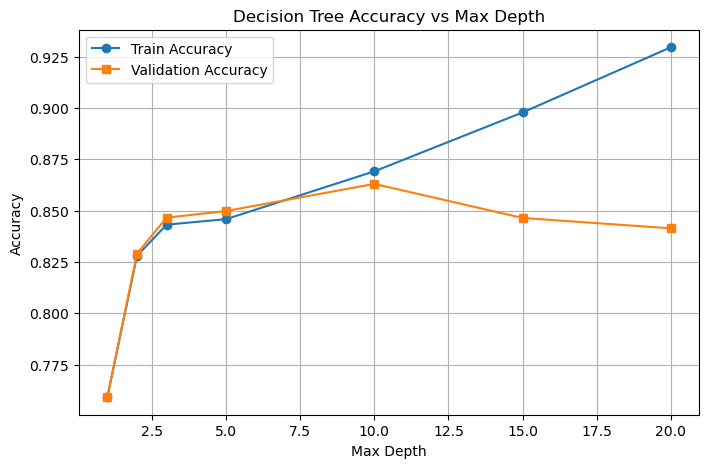

,max_depth,train_accuracy,validation_accuracy,node_count
0,1,0.759175,0.759251,3
1,2,0.828010,0.829111,7
2,3,0.843213,0.846614,15
3,5,0.845861,0.849839,55
4,10,0.869165,0.863043,469
5,15,0.897842,0.846461,1787
6,20,0.929592,0.841394,3435


In [8]:
X_train_full, X_test, y_train_full, y_test = load_adult_data()

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

adult_preprocessor = build_adult_preprocessor(X_train_sub)

depth_values = [1, 2, 3, 5, 10, 15, 20]

train_accuracies = []
val_accuracies = []
node_counts = []

for depth in depth_values:
    model = Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", DecisionTreeClassifier(
            criterion="entropy",
            max_depth=depth,
            random_state=SEED
        ))
    ])

    model.fit(X_train_sub, y_train_sub)

    train_pred = model.predict(X_train_sub)
    val_pred = model.predict(X_val)

    train_accuracies.append(accuracy_score(y_train_sub, train_pred))
    val_accuracies.append(accuracy_score(y_val, val_pred))

    tree_model = model.named_steps["classifier"]
    node_counts.append(tree_model.tree_.node_count)

plt.figure(figsize=(8, 5))
plt.plot(depth_values, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(depth_values, val_accuracies, marker="s", label="Validation Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()

depth_results = pd.DataFrame({
    "max_depth": depth_values,
    "train_accuracy": train_accuracies,
    "validation_accuracy": val_accuracies,
    "node_count": node_counts
})

display(depth_results)

1(c).b

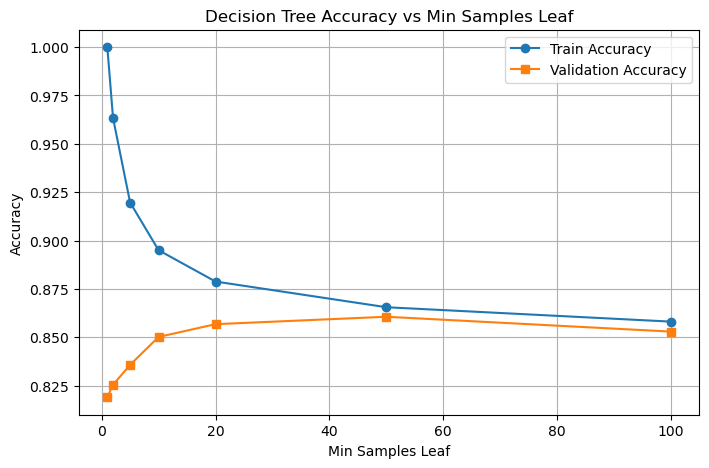

,min_samples_leaf,train_accuracy,validation_accuracy,node_count
0,1,0.999962,0.818977,7383
1,2,0.963375,0.825426,6279
2,5,0.919648,0.835713,3765
3,10,0.895002,0.850146,2243
4,20,0.878801,0.856748,1273
5,50,0.865518,0.860587,597
6,100,0.858070,0.852910,323


In [9]:
X_train_full, X_test, y_train_full, y_test = load_adult_data()

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

adult_preprocessor = build_adult_preprocessor(X_train_sub)

leaf_values = [1, 2, 5, 10, 20, 50, 100]

train_accuracies = []
val_accuracies = []
node_counts = []

for leaf_size in leaf_values:
    model = Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", DecisionTreeClassifier(
            criterion="entropy",
            min_samples_leaf=leaf_size,
            random_state=SEED
        ))
    ])

    model.fit(X_train_sub, y_train_sub)

    train_pred = model.predict(X_train_sub)
    val_pred = model.predict(X_val)

    train_accuracies.append(accuracy_score(y_train_sub, train_pred))
    val_accuracies.append(accuracy_score(y_val, val_pred))

    tree_model = model.named_steps["classifier"]
    node_counts.append(tree_model.tree_.node_count)

plt.figure(figsize=(8, 5))
plt.plot(leaf_values, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(leaf_values, val_accuracies, marker="s", label="Validation Accuracy")
plt.xlabel("Min Samples Leaf")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Min Samples Leaf")
plt.legend()
plt.grid(True)
plt.show()

leaf_results = pd.DataFrame({
    "min_samples_leaf": leaf_values,
    "train_accuracy": train_accuracies,
    "validation_accuracy": val_accuracies,
    "node_count": node_counts
})

display(leaf_results)

1(c).c

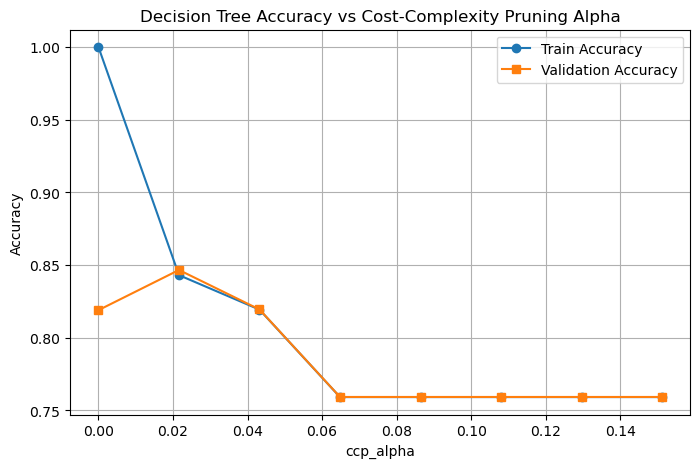

,ccp_alpha,train_accuracy,validation_accuracy,node_count
0,0.000000,0.999962,0.818977,7383
1,0.021601,0.843059,0.846614,9
2,0.043202,0.819334,0.819438,5
3,0.064802,0.759175,0.759251,3
4,0.086403,0.759175,0.759251,3
5,0.108004,0.759175,0.759251,3
6,0.129605,0.759175,0.759251,3
7,0.151206,0.759175,0.759251,1


In [10]:
X_train_full, X_test, y_train_full, y_test = load_adult_data()

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

adult_preprocessor = build_adult_preprocessor(X_train_sub)
X_train_sub_processed = adult_preprocessor.fit_transform(X_train_sub)
X_val_processed = adult_preprocessor.transform(X_val)

path_model = DecisionTreeClassifier(criterion="entropy", random_state=SEED)
ccp_path = path_model.cost_complexity_pruning_path(X_train_sub_processed, y_train_sub)

candidate_alphas = np.unique(ccp_path.ccp_alphas)
selected_alphas = np.linspace(candidate_alphas.min(), candidate_alphas.max(), 8)
selected_alphas = np.unique(np.round(selected_alphas, 6))

train_accuracies = []
val_accuracies = []
node_counts = []

for alpha in selected_alphas:
    clf = DecisionTreeClassifier(
        criterion="entropy",
        ccp_alpha=alpha,
        random_state=SEED
    )
    clf.fit(X_train_sub_processed, y_train_sub)

    train_pred = clf.predict(X_train_sub_processed)
    val_pred = clf.predict(X_val_processed)

    train_accuracies.append(accuracy_score(y_train_sub, train_pred))
    val_accuracies.append(accuracy_score(y_val, val_pred))
    node_counts.append(clf.tree_.node_count)

plt.figure(figsize=(8, 5))
plt.plot(selected_alphas, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(selected_alphas, val_accuracies, marker="s", label="Validation Accuracy")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Cost-Complexity Pruning Alpha")
plt.legend()
plt.grid(True)
plt.show()

alpha_results = pd.DataFrame({
    "ccp_alpha": selected_alphas,
    "train_accuracy": train_accuracies,
    "validation_accuracy": val_accuracies,
    "node_count": node_counts
})

display(alpha_results)

Problem2 (a)

In [11]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

forest_sizes = [10, 50, 100, 500]
results = []

for n_trees in forest_sizes:
    rf_model = Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=n_trees,
            random_state=SEED,
            n_jobs=-1
        ))
    ])

    rf_model.fit(X_train, y_train)

    train_pred = rf_model.predict(X_train)
    test_pred = rf_model.predict(X_test)

    train_score = rf_model.predict_proba(X_train)[:, 1]
    test_score = rf_model.predict_proba(X_test)[:, 1]

    train_metrics = compute_metrics(y_train, train_pred, train_score)
    test_metrics = compute_metrics(y_test, test_pred, test_score)

    results.append({
        "T": n_trees,
        "set": "train",
        "accuracy": train_metrics["accuracy"],
        "precision": train_metrics["precision"],
        "recall": train_metrics["recall"],
        "f1": train_metrics["f1"],
        "auc": train_metrics["auc"]
    })

    results.append({
        "T": n_trees,
        "set": "test",
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "auc": test_metrics["auc"]
    })

rf_results_df = pd.DataFrame(results)
display(rf_results_df)

,T,set,accuracy,precision,recall,f1,auc
0,10,train,0.986855,0.993345,0.951792,0.972125,0.999411
1,10,test,0.846201,0.717293,0.575923,0.638881,0.876903
2,50,train,0.999816,0.999872,0.999362,0.999617,0.999999
3,50,test,0.851299,0.719704,0.606864,0.658485,0.897766
4,100,train,0.999969,0.999872,1.000000,0.999936,1.000000
5,100,test,0.852098,0.720147,0.611544,0.661417,0.900813
6,500,train,0.999969,1.000000,0.999872,0.999936,1.000000
7,500,test,0.852098,0.719074,0.613625,0.662177,0.902497


2(b)

In [12]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

dt_model = Pipeline([
    ("preprocessor", adult_preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",
        random_state=SEED
    ))
])

rf_model_100 = Pipeline([
    ("preprocessor", adult_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    ))
])

comparison = []

for model_name, model in [
    ("Decision Tree (Entropy)", dt_model),
    ("Random Forest (100)", rf_model_100)
]:
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_score = model.predict_proba(X_train)[:, 1]
    test_score = model.predict_proba(X_test)[:, 1]

    train_metrics = compute_metrics(y_train, train_pred, train_score)
    test_metrics = compute_metrics(y_test, test_pred, test_score)

    comparison.append({
        "model": model_name,
        "set": "train",
        "accuracy": train_metrics["accuracy"],
        "precision": train_metrics["precision"],
        "recall": train_metrics["recall"],
        "f1": train_metrics["f1"],
        "auc": train_metrics["auc"]
    })

    comparison.append({
        "model": model_name,
        "set": "test",
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "auc": test_metrics["auc"]
    })

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

,model,set,accuracy,precision,recall,f1,auc
0,Decision Tree (Entropy),train,0.999969,1.000000,0.999872,0.999936,1.000000
1,Decision Tree (Entropy),test,0.814508,0.605143,0.618045,0.611526,0.746658
2,Random Forest (100),train,0.999969,0.999872,1.000000,0.999936,1.000000
3,Random Forest (100),test,0.852098,0.720147,0.611544,0.661417,0.900813


2(c)

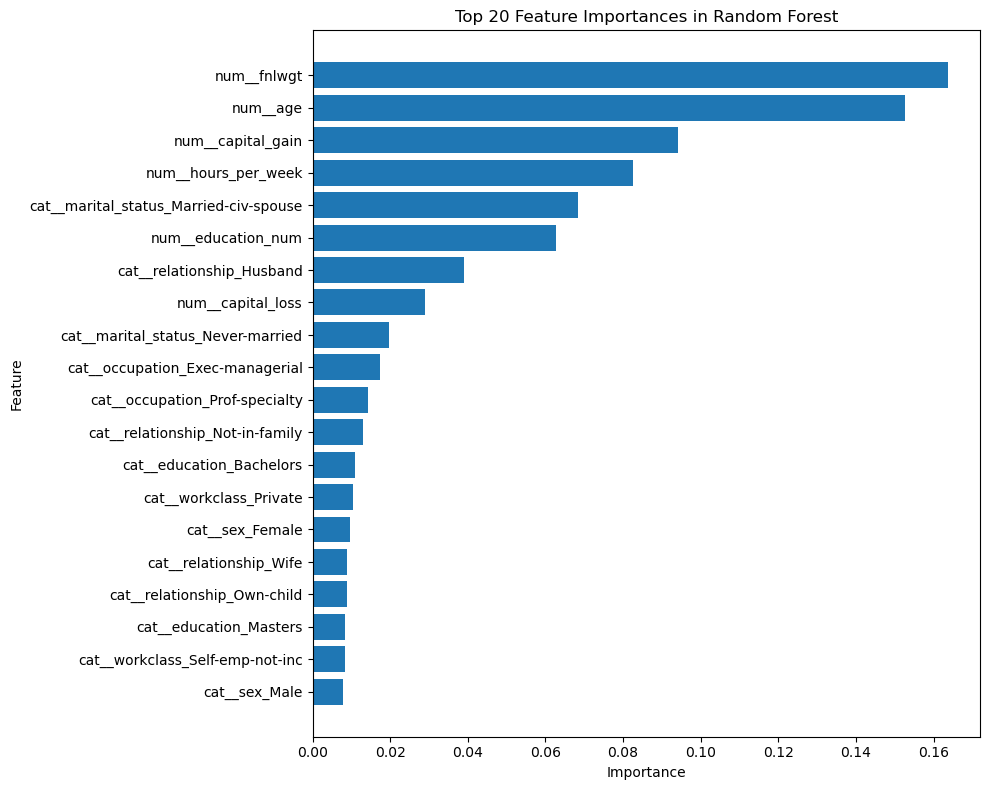

,feature,importance
1,num__fnlwgt,0.163778
0,num__age,0.152552
3,num__capital_gain,0.094236
5,num__hours_per_week,0.082519
33,cat__marital_status_Married-civ-spouse,0.068388
2,num__education_num,0.062854
53,cat__relationship_Husband,0.038937
4,num__capital_loss,0.028967
35,cat__marital_status_Never-married,0.019744
42,cat__occupation_Exec-managerial,0.017476


In [13]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

rf_model = Pipeline([
    ("preprocessor", adult_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

preprocessor = rf_model.named_steps["preprocessor"]
classifier = rf_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_k = 20
top_features = importance_df.head(top_k).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances in Random Forest")
plt.tight_layout()
plt.show()

display(importance_df.head(20))

3(a)

In [25]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

boost_sizes = [10, 50, 100, 500]
results = []

for n_estimators in boost_sizes:
    ada_model = Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
            n_estimators=n_estimators,
            learning_rate=0.1,
            random_state=SEED
        ))
    ])

    gb_model = Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=0.1,
            max_depth=3,
            random_state=SEED
        ))
    ])

    for model_name, model in [("AdaBoost", ada_model), ("GradientBoost", gb_model)]:
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]

        train_metrics = compute_metrics(y_train, train_pred, train_score)
        test_metrics = compute_metrics(y_test, test_pred, test_score)

        results.append({
            "model": model_name,
            "T": n_estimators,
            "set": "train",
            "accuracy": train_metrics["accuracy"],
            "precision": train_metrics["precision"],
            "recall": train_metrics["recall"],
            "f1": train_metrics["f1"],
            "auc": train_metrics["auc"]
        })

        results.append({
            "model": model_name,
            "T": n_estimators,
            "set": "test",
            "accuracy": test_metrics["accuracy"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
            "auc": test_metrics["auc"]
        })

boost_results_df = pd.DataFrame(results)
display(boost_results_df)

D:\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,model,T,set,accuracy,precision,recall,f1,auc
0,AdaBoost,10,train,0.849083,0.777231,0.523275,0.625457,0.896848
1,AdaBoost,10,test,0.850808,0.774932,0.519241,0.621828,0.896981
2,GradientBoost,10,train,0.844845,0.819620,0.456064,0.586037,0.889754
3,GradientBoost,10,test,0.847368,0.821749,0.451898,0.583124,0.890513
4,AdaBoost,50,train,0.862566,0.802589,0.569315,0.666120,0.922881
5,AdaBoost,50,test,0.866593,0.805029,0.574363,0.670410,0.919542
6,GradientBoost,50,train,0.861337,0.796752,0.569443,0.664187,0.917717
7,GradientBoost,50,test,0.864320,0.796881,0.571243,0.665455,0.914897
8,AdaBoost,100,train,0.872793,0.798644,0.630787,0.704860,0.933468
9,AdaBoost,100,test,0.876052,0.799476,0.634425,0.707451,0.927167


3(b)

In [19]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

ensemble_sizes = [10, 50, 100, 500]
comparison_results = []

for n_estimators in ensemble_sizes:
    models = {
        "RandomForest": Pipeline([
            ("preprocessor", adult_preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=n_estimators,
                random_state=SEED,
                n_jobs=-1
            ))
        ]),
        "AdaBoost": Pipeline([
            ("preprocessor", adult_preprocessor),
            ("classifier", AdaBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
                n_estimators=n_estimators,
                learning_rate=0.1,
                algorithm="SAMME",
                random_state=SEED
            ))
        ]),
        "GradientBoost": Pipeline([
            ("preprocessor", adult_preprocessor),
            ("classifier", GradientBoostingClassifier(
                n_estimators=n_estimators,
                learning_rate=0.1,
                max_depth=3,
                random_state=SEED
            ))
        ])
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_score = model.predict_proba(X_train)[:, 1]
        test_score = model.predict_proba(X_test)[:, 1]

        train_metrics = compute_metrics(y_train, train_pred, train_score)
        test_metrics = compute_metrics(y_test, test_pred, test_score)

        comparison_results.append({
            "model": model_name,
            "T": n_estimators,
            "set": "train",
            "accuracy": train_metrics["accuracy"],
            "precision": train_metrics["precision"],
            "recall": train_metrics["recall"],
            "f1": train_metrics["f1"],
            "auc": train_metrics["auc"]
        })

        comparison_results.append({
            "model": model_name,
            "T": n_estimators,
            "set": "test",
            "accuracy": test_metrics["accuracy"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
            "auc": test_metrics["auc"]
        })

comparison_results_df = pd.DataFrame(comparison_results)
display(comparison_results_df)

,model,T,set,accuracy,precision,recall,f1,auc
0,RandomForest,10,train,0.986855,0.993345,0.951792,0.972125,0.999411
1,RandomForest,10,test,0.846201,0.717293,0.575923,0.638881,0.876903
2,AdaBoost,10,train,0.848623,0.759444,0.543553,0.633613,0.869533
3,AdaBoost,10,test,0.849886,0.757910,0.535621,0.627666,0.869922
4,GradientBoost,10,train,0.844845,0.819620,0.456064,0.586037,0.889754
5,GradientBoost,10,test,0.847368,0.821749,0.451898,0.583124,0.890513
6,RandomForest,50,train,0.999816,0.999872,0.999362,0.999617,0.999999
7,RandomForest,50,test,0.851299,0.719704,0.606864,0.658485,0.897766
8,AdaBoost,50,train,0.853506,0.794326,0.528504,0.634707,0.906436
9,AdaBoost,50,test,0.854432,0.790094,0.522621,0.629108,0.905327


3(c)

D:\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


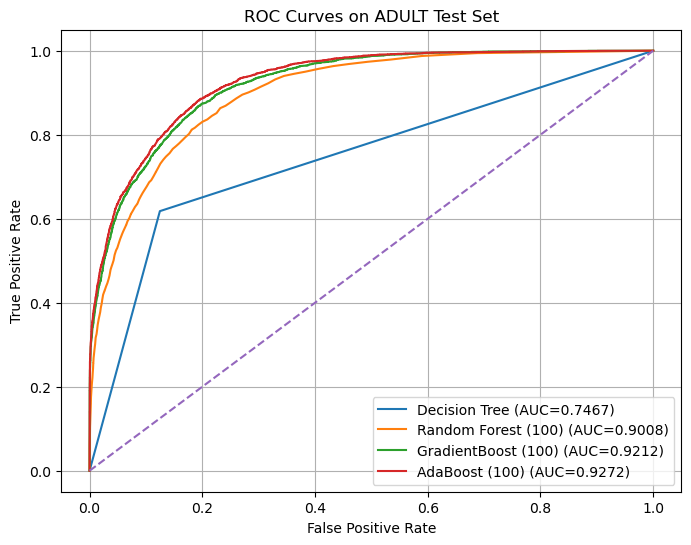

In [17]:
X_train, X_test, y_train, y_test = load_adult_data()
adult_preprocessor = build_adult_preprocessor(X_train)

models = {
    "Decision Tree": Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", DecisionTreeClassifier(
            criterion="entropy",
            random_state=SEED
        ))
    ]),
    "Random Forest (100)": Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=SEED,
            n_jobs=-1
        ))
    ]),
    "GradientBoost (100)": Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=SEED
        ))
    ]),
    "AdaBoost (100)": Pipeline([
        ("preprocessor", adult_preprocessor),
        ("classifier", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
            n_estimators=100,
            learning_rate=0.1,
            random_state=SEED
        ))
    ])
}

plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on ADULT Test Set")
plt.legend()
plt.grid(True)
plt.show()

4(a)

In [20]:
# Fit custom categorical Naive Bayes
class CustomNaiveBayes:
    # Initialize model storage
    def __init__(self):
        self.class_priors = {}
        self.feature_cond_probs = {}
        self.classes_ = None
        self.feature_values_ = {}
        self.class_counts_ = {}

    # Train model with Laplace smoothing
    def fit(self, X, y):
        X = X.reset_index(drop=True).copy()
        y = pd.Series(y).reset_index(drop=True)

        self.classes_ = sorted(y.unique())
        self.class_counts_ = y.value_counts().to_dict()

        for col in X.columns:
            self.feature_values_[col] = sorted(X[col].unique())

        n_samples = len(y)

        for c in self.classes_:
            self.class_priors[c] = self.class_counts_[c] / n_samples

        for col in X.columns:
            self.feature_cond_probs[col] = {}
            values = self.feature_values_[col]
            k = len(values)

            for c in self.classes_:
                mask = (y == c)
                X_c = X.loc[mask, :]
                counts = X_c[col].value_counts().to_dict()
                total_c = len(X_c)

                self.feature_cond_probs[col][c] = {}
                for v in values:
                    count = counts.get(v, 0)
                    prob = (count + 1) / (total_c + k)
                    self.feature_cond_probs[col][c][v] = prob

    # Predict class probabilities
    def predict_proba(self, X):
        X = X.reset_index(drop=True).copy()
        prob_rows = []

        for _, row in X.iterrows():
            log_probs = {}

            for c in self.classes_:
                log_prob = math.log(self.class_priors[c])

                for col in X.columns:
                    value = row[col]
                    if value in self.feature_cond_probs[col][c]:
                        prob = self.feature_cond_probs[col][c][value]
                    else:
                        k = len(self.feature_values_[col])
                        total_c = self.class_counts_[c]
                        prob = 1 / (total_c + k)
                    log_prob += math.log(prob)

                log_probs[c] = log_prob

            max_log = max(log_probs.values())
            exp_probs = {c: math.exp(log_probs[c] - max_log) for c in self.classes_}
            total = sum(exp_probs.values())
            normalized = [exp_probs[c] / total for c in self.classes_]
            prob_rows.append(normalized)

        return np.array(prob_rows)

    # Predict class labels
    def predict(self, X):
        probs = self.predict_proba(X)
        return np.array(self.classes_)[np.argmax(probs, axis=1)]

In [21]:
X, y = load_mushroom_data()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

custom_nb = CustomNaiveBayes()
custom_nb.fit(X_train, y_train)

print("Class priors:")
print(custom_nb.class_priors)

first_feature = X_train.columns[0]
print(f"\nConditional probabilities for feature: {first_feature}")
display(pd.DataFrame(custom_nb.feature_cond_probs[first_feature]).T)

Class priors:
{0: 0.517971442639094, 1: 0.48202855736090594}

Conditional probabilities for feature: cap-shape


,b,c,f,k,s,x
0,0.093612,0.000316,0.375079,0.054712,0.007906,0.468374
1,0.012912,0.001699,0.395515,0.148488,0.000340,0.441047


4(b)

In [22]:
X, y = load_mushroom_data()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

custom_nb = CustomNaiveBayes()
custom_nb.fit(X_train, y_train)

test_proba = custom_nb.predict_proba(X_test)

proba_df = pd.DataFrame(test_proba, columns=["P(Edible=0)", "P(Poisonous=1)"])
display(proba_df.head(20))

,P(Edible=0),P(Poisonous=1)
0,1.000000e+00,3.600629e-08
1,3.864316e-10,1.000000e+00
2,9.999970e-01,2.982959e-06
3,9.794624e-01,2.053762e-02
4,7.960977e-13,1.000000e+00
5,9.999948e-01,5.199634e-06
6,1.921995e-12,1.000000e+00
7,1.157036e-09,1.000000e+00
8,1.000000e+00,1.554688e-09
9,7.316793e-01,2.683207e-01


4(c)

In [23]:
X, y = load_mushroom_data()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

custom_nb = CustomNaiveBayes()
custom_nb.fit(X_train, y_train)

y_pred = custom_nb.predict(X_test)

custom_results = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0)
}])

display(custom_results)

,accuracy,precision,recall,f1
0,0.952733,0.991101,0.910112,0.948882


4(d)

In [24]:
X, y = load_mushroom_data()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

custom_nb = CustomNaiveBayes()
custom_nb.fit(X_train, y_train)
custom_pred = custom_nb.predict(X_test)

X_train_enc = X_train.reset_index(drop=True).copy()
X_test_enc = X_test.reset_index(drop=True).copy()

for col in X_train.columns:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col])
    X_test_enc[col] = le.transform(X_test_enc[col])

package_nb = CategoricalNB()
package_nb.fit(X_train_enc, y_train.reset_index(drop=True))
package_pred = package_nb.predict(X_test_enc)

comparison_df = pd.DataFrame([
    {
        "model": "Custom Naive Bayes",
        "accuracy": accuracy_score(y_test, custom_pred),
        "precision": precision_score(y_test, custom_pred, zero_division=0),
        "recall": recall_score(y_test, custom_pred, zero_division=0),
        "f1": f1_score(y_test, custom_pred, zero_division=0)
    },
    {
        "model": "CategoricalNB",
        "accuracy": accuracy_score(y_test, package_pred),
        "precision": precision_score(y_test, package_pred, zero_division=0),
        "recall": recall_score(y_test, package_pred, zero_division=0),
        "f1": f1_score(y_test, package_pred, zero_division=0)
    }
])

display(comparison_df)

,model,accuracy,precision,recall,f1
0,Custom Naive Bayes,0.952733,0.991101,0.910112,0.948882
1,CategoricalNB,0.952733,0.991101,0.910112,0.948882
